In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# load the data

data_path = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\final_smoothed_time_series.csv"

df = pd.read_csv(data_path, parse_dates=["tpep_pickup_datetime"])

In [3]:
df['avg_pickups'].max()

819.8083311283476

In [4]:
# datatypes

df.dtypes

tpep_pickup_datetime    datetime64[ns]
region                           int64
total_pickups                    int64
avg_pickups                    float64
dtype: object

In [5]:
# check for missing values

df.isna().sum()

tpep_pickup_datetime    0
region                  0
total_pickups           0
avg_pickups             0
dtype: int64

In [6]:

# extract the day of week information
df["day_of_week"] = df["tpep_pickup_datetime"].dt.day_of_week

# extract the month information
df["month"] = df["tpep_pickup_datetime"].dt.month

In [7]:
# set the datetime column as index

df.set_index("tpep_pickup_datetime", inplace=True)

In [8]:
df

,region,total_pickups,avg_pickups,day_of_week,month
tpep_pickup_datetime,,,,,
2016-01-01 00:00:00,0,138,138.000000,4,1
2016-01-01 00:00:00,11,156,156.000000,4,1
2016-01-01 00:00:00,14,33,33.000000,4,1
2016-01-01 00:00:00,10,126,126.000000,4,1
2016-01-01 00:00:00,15,166,166.000000,4,1
...,...,...,...,...,...
2016-03-31 23:45:00,24,295,295.011212,3,3
2016-03-31 23:45:00,25,283,305.794516,3,3
2016-03-31 23:45:00,26,317,338.551044,3,3


In [9]:
# create the region grouper

region_grp = df.groupby("region")

region_grp

In [10]:
# shifting periods

periods = list(range(1,5))

periods

[1, 2, 3, 4]

In [11]:
# generate the lag features

lag_features = region_grp["total_pickups"].shift(periods)

lag_features

,total_pickups_1,total_pickups_2,total_pickups_3,total_pickups_4
tpep_pickup_datetime,,,,
2016-01-01 00:00:00,NaN,NaN,NaN,NaN
2016-01-01 00:00:00,NaN,NaN,NaN,NaN
2016-01-01 00:00:00,NaN,NaN,NaN,NaN
2016-01-01 00:00:00,NaN,NaN,NaN,NaN
2016-01-01 00:00:00,NaN,NaN,NaN,NaN
...,...,...,...,...
2016-03-31 23:45:00,297.0,287.0,279.0,335.0
2016-03-31 23:45:00,335.0,346.0,325.0,317.0
2016-03-31 23:45:00,337.0,410.0,371.0,381.0


In [12]:
# merge them with the original df

data = pd.concat([lag_features,df],axis=1)



In [13]:
data.sort_values(by=["region","tpep_pickup_datetime"])

,total_pickups_1,total_pickups_2,total_pickups_3,total_pickups_4,region,total_pickups,avg_pickups,day_of_week,month
tpep_pickup_datetime,,,,,,,,,
2016-01-01 00:00:00,NaN,NaN,NaN,NaN,0,138,138.000000,4,1
2016-01-01 00:15:00,138.0,NaN,NaN,NaN,0,326,241.400000,4,1
2016-01-01 00:30:00,326.0,138.0,NaN,NaN,0,235,237.880000,4,1
2016-01-01 00:45:00,235.0,326.0,138.0,NaN,0,241,239.596000,4,1
2016-01-01 01:00:00,241.0,235.0,326.0,138.0,0,250,245.318200,4,1
...,...,...,...,...,...,...,...,...,...
2016-03-31 22:45:00,267.0,215.0,295.0,277.0,29,241,249.550969,3,3
2016-03-31 23:00:00,241.0,267.0,215.0,295.0,29,194,218.997936,3,3
2016-03-31 23:15:00,194.0,241.0,267.0,215.0,29,180,197.549071,3,3


In [14]:
print("The shape of the df before merger ", df.shape)
print("The shape of the df after merger ", data.shape)

The shape of the df before merger  (262080, 5)
The shape of the df after merger  (262080, 9)


In [15]:
# rows having missing values

data.isna().any(axis=1).sum()

120

In [16]:
# drop the missing values

data.dropna(inplace=True)

In [17]:
data.isna().any(axis=1).sum()

0

In [18]:
mapper = {name:f"lag_{ind+1}" for ind, name in enumerate(data.columns[0:4])}

mapper

{'total_pickups_1': 'lag_1',
 'total_pickups_2': 'lag_2',
 'total_pickups_3': 'lag_3',
 'total_pickups_4': 'lag_4'}

In [19]:

# replace the column names

data = data.rename(columns=mapper)

In [20]:
data.head()

,lag_1,lag_2,lag_3,lag_4,region,total_pickups,avg_pickups,day_of_week,month
tpep_pickup_datetime,,,,,,,,,
2016-01-01 01:00:00,241.0,235.0,326.0,138.0,0,250,245.318200,4,1
2016-01-01 01:00:00,117.0,124.0,92.0,30.0,22,121,115.159113,4,1
2016-01-01 01:00:00,284.0,246.0,253.0,157.0,18,257,258.156275,4,1
2016-01-01 01:00:00,306.0,401.0,416.0,239.0,6,251,289.096269,4,1
2016-01-01 01:00:00,387.0,422.0,402.0,156.0,11,413,396.477463,4,1


In [21]:
# shape of the data

data.shape

(261960, 9)

In [22]:
# number of rows in each month

data['month'].value_counts()

month
3    89280
1    89160
2    83520
Name: count, dtype: int64

In [23]:
data.loc[data["month"].isin([1,2]),"lag_1":"day_of_week"]

,lag_1,lag_2,lag_3,lag_4,region,total_pickups,avg_pickups,day_of_week
tpep_pickup_datetime,,,,,,,,
2016-01-01 01:00:00,241.0,235.0,326.0,138.0,0,250,245.318200,4
2016-01-01 01:00:00,117.0,124.0,92.0,30.0,22,121,115.159113,4
2016-01-01 01:00:00,284.0,246.0,253.0,157.0,18,257,258.156275,4
2016-01-01 01:00:00,306.0,401.0,416.0,239.0,6,251,289.096269,4
2016-01-01 01:00:00,387.0,422.0,402.0,156.0,11,413,396.477463,4
...,...,...,...,...,...,...,...,...
2016-02-29 23:45:00,205.0,231.0,314.0,270.0,8,175,200.718125,0
2016-02-29 23:45:00,16.0,6.0,9.0,9.0,21,11,11.504424,0
2016-02-29 23:45:00,140.0,171.0,177.0,206.0,6,118,136.046955,0


In [24]:
# split the data

trainset = data.loc[data["month"].isin([1,2]),"lag_1":"day_of_week"]

testset = data.loc[data["month"].isin([3]),"lag_1":"day_of_week"]

In [25]:

trainset 

,lag_1,lag_2,lag_3,lag_4,region,total_pickups,avg_pickups,day_of_week
tpep_pickup_datetime,,,,,,,,
2016-01-01 01:00:00,241.0,235.0,326.0,138.0,0,250,245.318200,4
2016-01-01 01:00:00,117.0,124.0,92.0,30.0,22,121,115.159113,4
2016-01-01 01:00:00,284.0,246.0,253.0,157.0,18,257,258.156275,4
2016-01-01 01:00:00,306.0,401.0,416.0,239.0,6,251,289.096269,4
2016-01-01 01:00:00,387.0,422.0,402.0,156.0,11,413,396.477463,4
...,...,...,...,...,...,...,...,...
2016-02-29 23:45:00,205.0,231.0,314.0,270.0,8,175,200.718125,0
2016-02-29 23:45:00,16.0,6.0,9.0,9.0,21,11,11.504424,0
2016-02-29 23:45:00,140.0,171.0,177.0,206.0,6,118,136.046955,0


In [26]:
# save the train and test data

train_data_save_path = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\train.csv"

test_data_save_path = r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\test.csv"

trainset.to_csv(train_data_save_path, index=True)
testset.to_csv(test_data_save_path, index=True)

NameError: name 'train' is not defined

In [27]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

# Define features and target
features = ["lag_1", "lag_2", "lag_3", "lag_4", "region", "avg_pickups", "day_of_week"]
target = "total_pickups"

X_train, y_train = trainset[features], trainset[target]
X_test, y_test = testset[features], testset[target]

# Train XGBoost
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# Predict
y_pred = xgb_model.predict(X_test)

# Evaluate
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"✅ XGBoost MAPE: {mape:.3f}")


✅ XGBoost MAPE: 0.047


✅ New Features: ['lag_1', 'lag_2', 'lag_3', 'lag_4', 'region', 'avg_pickups', 'day_of_week', 'rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'rolling_std_6']

✅ XGBoost with Rolling Features MAPE: 0.061


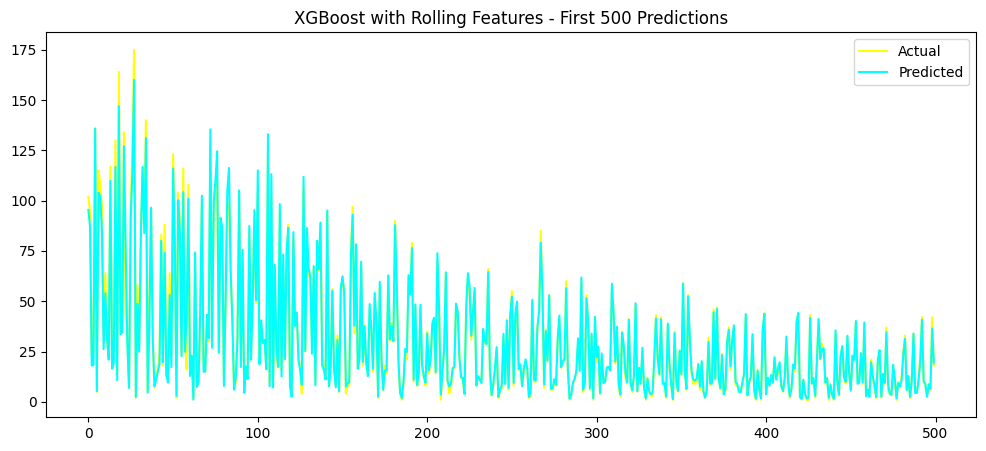

In [69]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd

# =======================
# STEP 1️⃣: Define features
# =======================
features = ["lag_1", "lag_2", "lag_3", "lag_4", "region", "avg_pickups", "day_of_week"]
target = "total_pickups"

# =======================
# STEP 2️⃣: Add rolling mean & std features
# =======================

# Choose rolling window sizes (you can tune this)
rolling_windows = [3, 6]  # 3 = last 45 min, 6 = last 1.5 hours

for w in rolling_windows:
    trainset[f'rolling_mean_{w}'] = trainset.groupby('region')['total_pickups'].transform(lambda x: x.rolling(window=w).mean())
    trainset[f'rolling_std_{w}']  = trainset.groupby('region')['total_pickups'].transform(lambda x: x.rolling(window=w).std())
    
    testset[f'rolling_mean_{w}'] = testset.groupby('region')['total_pickups'].transform(lambda x: x.rolling(window=w).mean())
    testset[f'rolling_std_{w}']  = testset.groupby('region')['total_pickups'].transform(lambda x: x.rolling(window=w).std())

# Fill any missing values (especially first few rows)
trainset.fillna(method='bfill', inplace=True)
testset.fillna(method='bfill', inplace=True)

# Add new rolling features to feature list
features += [f'rolling_mean_{w}' for w in rolling_windows]
features += [f'rolling_std_{w}' for w in rolling_windows]

print("✅ New Features:", features)

# =======================
# STEP 3️⃣: Train/Test Split
# =======================
X_train, y_train = trainset[features], trainset[target]
X_test, y_test = testset[features], testset[target]

# =======================
# STEP 4️⃣: Train XGBoost
# =======================
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
xgb_model.fit(X_train, y_train)

# =======================
# STEP 5️⃣: Predict & Evaluate
# =======================
y_pred = xgb_model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)

print(f"\n✅ XGBoost with Rolling Features MAPE: {mape:.3f}")

# =======================
# STEP 6️⃣: Visualize Actual vs Predicted
# =======================
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(y_test.values[:500], label="Actual", color="yellow")
plt.plot(y_pred[:500], label="Predicted", color="cyan")
plt.title("XGBoost with Rolling Features - First 500 Predictions")
plt.legend()
plt.show()


In [70]:
trainset

,tpep_pickup_datetime,lag_1,lag_2,lag_3,lag_4,region,total_pickups,avg_pickups,day_of_week,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6
0,2016-01-01 01:00:00,241.0,235.0,326.0,138.0,0,250,245.318200,4,199.666667,14.977761,21.000000,5.932959
1,2016-01-01 01:00:00,117.0,124.0,92.0,30.0,22,121,115.159113,4,199.666667,14.977761,21.000000,5.932959
2,2016-01-01 01:00:00,284.0,246.0,253.0,157.0,18,257,258.156275,4,199.666667,14.977761,21.000000,5.932959
3,2016-01-01 01:00:00,306.0,401.0,416.0,239.0,6,251,289.096269,4,199.666667,14.977761,21.000000,5.932959
4,2016-01-01 01:00:00,387.0,422.0,402.0,156.0,11,413,396.477463,4,199.666667,14.977761,21.000000,5.932959
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172675,2016-02-29 23:45:00,205.0,231.0,314.0,270.0,8,175,200.718125,0,203.666667,28.023799,253.666667,60.589328
172676,2016-02-29 23:45:00,16.0,6.0,9.0,9.0,21,11,11.504424,0,11.000000,5.000000,10.166667,3.311596
172677,2016-02-29 23:45:00,140.0,171.0,177.0,206.0,6,118,136.046955,0,143.000000,26.627054,166.833333,32.406275
172678,2016-02-29 23:45:00,49.0,64.0,67.0,77.0,15,30,42.534871,0,47.666667,17.039171,60.166667,17.724747


In [55]:
trainset

,tpep_pickup_datetime,lag_1,lag_2,lag_3,lag_4,region,total_pickups,avg_pickups,day_of_week,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6
0,2016-01-01 01:00:00,241.0,235.0,326.0,138.0,0,250,245.318200,4,199.666667,14.977761,21.000000,5.932959
1,2016-01-01 01:00:00,117.0,124.0,92.0,30.0,22,121,115.159113,4,199.666667,14.977761,21.000000,5.932959
2,2016-01-01 01:00:00,284.0,246.0,253.0,157.0,18,257,258.156275,4,199.666667,14.977761,21.000000,5.932959
3,2016-01-01 01:00:00,306.0,401.0,416.0,239.0,6,251,289.096269,4,199.666667,14.977761,21.000000,5.932959
4,2016-01-01 01:00:00,387.0,422.0,402.0,156.0,11,413,396.477463,4,199.666667,14.977761,21.000000,5.932959
...,...,...,...,...,...,...,...,...,...,...,...,...,...
172675,2016-02-29 23:45:00,205.0,231.0,314.0,270.0,8,175,200.718125,0,203.666667,28.023799,253.666667,60.589328
172676,2016-02-29 23:45:00,16.0,6.0,9.0,9.0,21,11,11.504424,0,11.000000,5.000000,10.166667,3.311596
172677,2016-02-29 23:45:00,140.0,171.0,177.0,206.0,6,118,136.046955,0,143.000000,26.627054,166.833333,32.406275
172678,2016-02-29 23:45:00,49.0,64.0,67.0,77.0,15,30,42.534871,0,47.666667,17.039171,60.166667,17.724747


In [29]:
from sklearn.metrics import mean_absolute_percentage_error
import numpy as np

region_mape = {}

for r in trainset['region'].unique():
    r_train = trainset[trainset['region'] == r]
    r_test  = testset[testset['region'] == r]

    if len(r_train) < 500:  # skip small ones
        continue

    X_train, y_train = r_train[features], r_train[target]
    X_test, y_test   = r_test[features], r_test[target]

    model = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42)
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    region_mape[r] = mape
    print(f"Region {r}: MAPE = {mape:.4f}")

print("\n📊 Avg Region-wise MAPE:", np.mean(list(region_mape.values())))


Region 0: MAPE = 0.0317
Region 22: MAPE = 0.0243
Region 18: MAPE = 0.0344
Region 6: MAPE = 0.0339
Region 11: MAPE = 0.0314
Region 25: MAPE = 0.0383
Region 16: MAPE = 0.0561
Region 14: MAPE = 0.0279
Region 4: MAPE = 0.0761
Region 12: MAPE = 0.0462
Region 24: MAPE = 0.0329
Region 10: MAPE = 0.0247
Region 20: MAPE = 0.0207
Region 23: MAPE = 0.0304
Region 3: MAPE = 0.0238
Region 26: MAPE = 0.0327
Region 27: MAPE = 0.0214
Region 8: MAPE = 0.0335
Region 13: MAPE = 0.0228
Region 15: MAPE = 0.0336
Region 29: MAPE = 0.0281
Region 9: MAPE = 0.0226
Region 17: MAPE = 0.0306
Region 21: MAPE = 0.0446
Region 5: MAPE = 0.0358
Region 1: MAPE = 0.1151
Region 7: MAPE = 0.0286
Region 19: MAPE = 0.0353
Region 28: MAPE = 0.0457
Region 2: MAPE = 0.0472

📊 Avg Region-wise MAPE: 0.03701192314426104


In [30]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# Pick a region
region_id = 10

# Filter train and test by region
train_region = trainset[trainset["region"] == region_id].sort_index()
test_region  = testset[testset["region"] == region_id].sort_index()

# Extract target series
train_series = train_region["total_pickups"].asfreq("15min").fillna(method="ffill")
test_series  = test_region["total_pickups"].asfreq("15min").fillna(method="ffill")

print("Train range:", train_series.index.min(), "→", train_series.index.max())
print("Test range:", test_series.index.min(), "→", test_series.index.max())


Train range: 2016-01-01 01:00:00 → 2016-02-29 23:45:00
Test range: 2016-03-01 00:00:00 → 2016-03-31 23:45:00


🚀 Training SARIMA for Region 10...
Training points: 2688, Testing points: 2976
✅ SARIMA model fitted successfully for region 10
📊 SARIMA (Region 10) MAPE: 1.0350


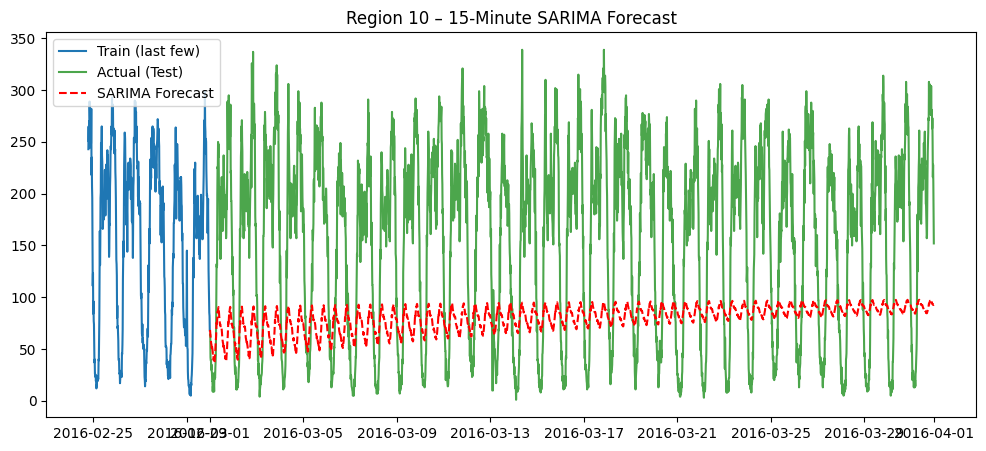

In [36]:
import pandas as pd
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore")

# 🧩 Choose one region (example: 3)
region_id = 10
print(f"🚀 Training SARIMA for Region {region_id}...")

# 1️⃣ Filter train & test for that region
train_region = (
    trainset[trainset["region"] == region_id]
    .sort_index()
)
test_region = (
    testset[testset["region"] == region_id]
    .sort_index()
)

# 2️⃣ Limit training data to recent 4 weeks to prevent RAM overload
train_region = train_region.last("28D")

# Extract the target time series
train_series = train_region["total_pickups"]
test_series = test_region["total_pickups"]

print(f"Training points: {len(train_series)}, Testing points: {len(test_series)}")

# Skip if not enough data
if len(train_series) < 200:
    raise ValueError(f"⚠️ Not enough data for region {region_id}")

# 3️⃣ Fit a lightweight SARIMA model (optimized for 15-min data)
model = SARIMAX(
    train_series,
    order=(1, 1, 1),
    seasonal_order=(1, 0, 1, 48),  # half-day seasonal pattern (reduces memory)
    enforce_stationarity=False,
    enforce_invertibility=False
)

result = model.fit(disp=False, low_memory=True)
print(f"✅ SARIMA model fitted successfully for region {region_id}")

# 4️⃣ Forecast for the test period
forecast = result.forecast(steps=len(test_series))

# 5️⃣ Evaluate accuracy
mape = mean_absolute_percentage_error(test_series, forecast)
print(f"📊 SARIMA (Region {region_id}) MAPE: {mape:.4f}")

# 6️⃣ Visualize the results
plt.figure(figsize=(12, 5))
plt.plot(train_series[-500:], label="Train (last few)")
plt.plot(test_series, label="Actual (Test)", color="green", alpha=0.7)
plt.plot(forecast, label="SARIMA Forecast", color="red", linestyle="--")
plt.title(f"Region {region_id} – 15-Minute SARIMA Forecast")
plt.legend()
plt.show()


🗺️ Region 10: Train = 5756, Test = 2976
✅ Prophet train/test ready:
🚀 Training Prophet model...


16:26:27 - cmdstanpy - INFO - Chain [1] start processing
16:26:35 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet MAPE for region 10: 0.6131


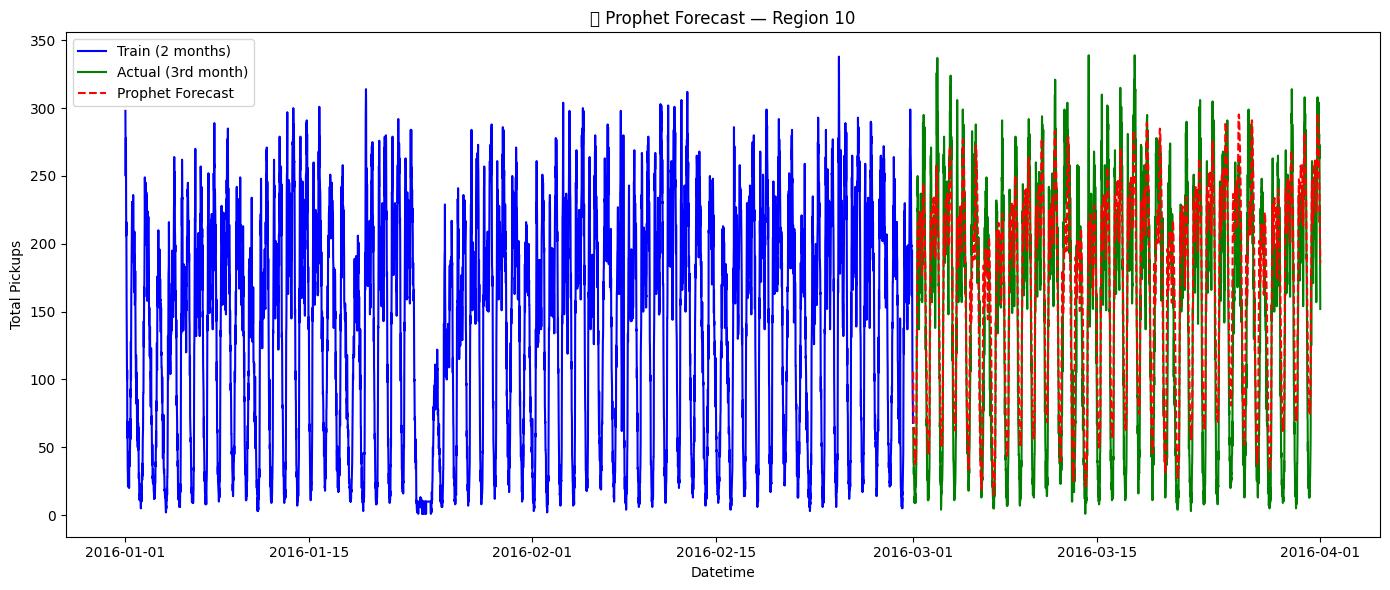

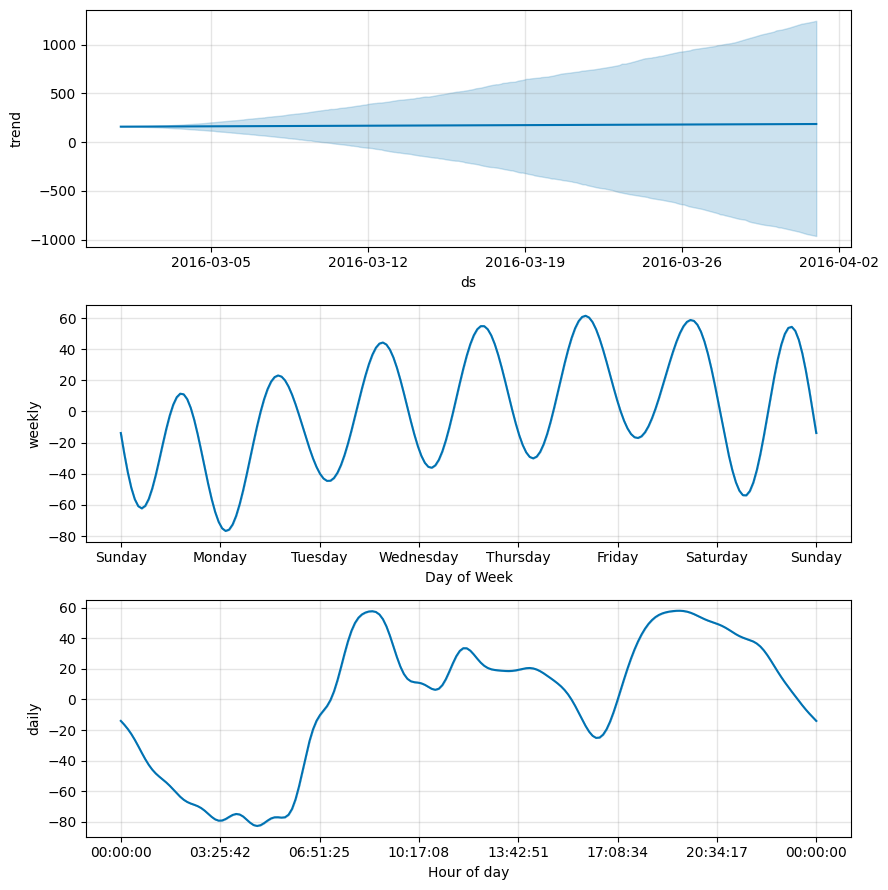

In [68]:
# ===============================================
# 🚕 Prophet on your existing train/test datasets
# ===============================================

import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

# -----------------------------------------------
# 1️⃣ Select one region (example: region 10)
# -----------------------------------------------
region_id = 10

train_region = trainset[trainset["region"] == region_id].copy()
test_region  = testset[testset["region"] == region_id].copy()

print(f"🗺️ Region {region_id}: Train = {len(train_region)}, Test = {len(test_region)}")

# -----------------------------------------------
# 2️⃣ Reset index to get datetime column back
# -----------------------------------------------
train_region = train_region.reset_index()   # brings 'tpep_pickup_datetime' back as a column
test_region  = test_region.reset_index()

# -----------------------------------------------
# 3️⃣ Prepare Prophet-friendly format
# -----------------------------------------------
prophet_train = train_region.rename(columns={"tpep_pickup_datetime": "ds", "total_pickups": "y"})
prophet_test  = test_region.rename(columns={"tpep_pickup_datetime": "ds", "total_pickups": "y"})

# Ensure datetime type
prophet_train["ds"] = pd.to_datetime(prophet_train["ds"])
prophet_test["ds"]  = pd.to_datetime(prophet_test["ds"])

print("✅ Prophet train/test ready:")

# -----------------------------------------------
# 3️⃣ Initialize Prophet model
# -----------------------------------------------
m = Prophet(
    daily_seasonality=False,
    weekly_seasonality=False,
    yearly_seasonality=False,
    changepoint_prior_scale=0.5,
    seasonality_mode="additive"
)

# 15-min interval → 96 per day, add custom daily + weekly seasonality
m.add_seasonality(name="daily", period=1, fourier_order=20)   # 1 day cycle
m.add_seasonality(name="weekly", period=7, fourier_order=10)  # weekly cycle

# -----------------------------------------------
# 4️⃣ Train the model
# -----------------------------------------------
print("🚀 Training Prophet model...")
m.fit(prophet_train)

# -----------------------------------------------
# 5️⃣ Forecast for test timestamps
# -----------------------------------------------
future = pd.DataFrame({"ds": prophet_test["ds"]})
forecast = m.predict(future)

# -----------------------------------------------
# 6️⃣ Evaluate MAPE
# -----------------------------------------------
y_true = prophet_test["y"].values
y_pred = forecast["yhat"].values
mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"✅ Prophet MAPE for region {region_id}: {mape:.4f}")

# -----------------------------------------------
# 7️⃣ Plot Forecast vs Actual
# -----------------------------------------------
plt.figure(figsize=(14, 6))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Train (2 months)", color="blue")
plt.plot(prophet_test["ds"], prophet_test["y"], label="Actual (3rd month)", color="green")
plt.plot(forecast["ds"], forecast["yhat"], label="Prophet Forecast", color="red", linestyle="dashed")
plt.title(f"🚖 Prophet Forecast — Region {region_id}")
plt.xlabel("Datetime")
plt.ylabel("Total Pickups")
plt.legend()
plt.tight_layout()
plt.show()

# -----------------------------------------------
# 8️⃣ Show seasonal/trend components (optional)
# -----------------------------------------------
m.plot_components(forecast)
plt.show()


In [40]:
trainset

,lag_1,lag_2,lag_3,lag_4,region,total_pickups,avg_pickups,day_of_week,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6
tpep_pickup_datetime,,,,,,,,,,,,
2016-01-01 01:00:00,241.0,235.0,326.0,138.0,0,250,245.318200,4,199.666667,14.977761,21.000000,5.932959
2016-01-01 01:00:00,117.0,124.0,92.0,30.0,22,121,115.159113,4,199.666667,14.977761,21.000000,5.932959
2016-01-01 01:00:00,284.0,246.0,253.0,157.0,18,257,258.156275,4,199.666667,14.977761,21.000000,5.932959
2016-01-01 01:00:00,306.0,401.0,416.0,239.0,6,251,289.096269,4,199.666667,14.977761,21.000000,5.932959
2016-01-01 01:00:00,387.0,422.0,402.0,156.0,11,413,396.477463,4,199.666667,14.977761,21.000000,5.932959
...,...,...,...,...,...,...,...,...,...,...,...,...
2016-02-29 23:45:00,205.0,231.0,314.0,270.0,8,175,200.718125,0,203.666667,28.023799,253.666667,60.589328
2016-02-29 23:45:00,16.0,6.0,9.0,9.0,21,11,11.504424,0,11.000000,5.000000,10.166667,3.311596
2016-02-29 23:45:00,140.0,171.0,177.0,206.0,6,118,136.046955,0,143.000000,26.627054,166.833333,32.406275


🗺️ Region 10 — Train: (5756, 12), Test: (2976, 12)
Train hourly shape: (1439, 13), Test hourly shape: (744, 13)
🚀 Training Prophet model (hourly)...


14:54:16 - cmdstanpy - INFO - Chain [1] start processing
14:54:16 - cmdstanpy - INFO - Chain [1] done processing


✅ Prophet MAPE (Region 10 — Hourly): 0.6279


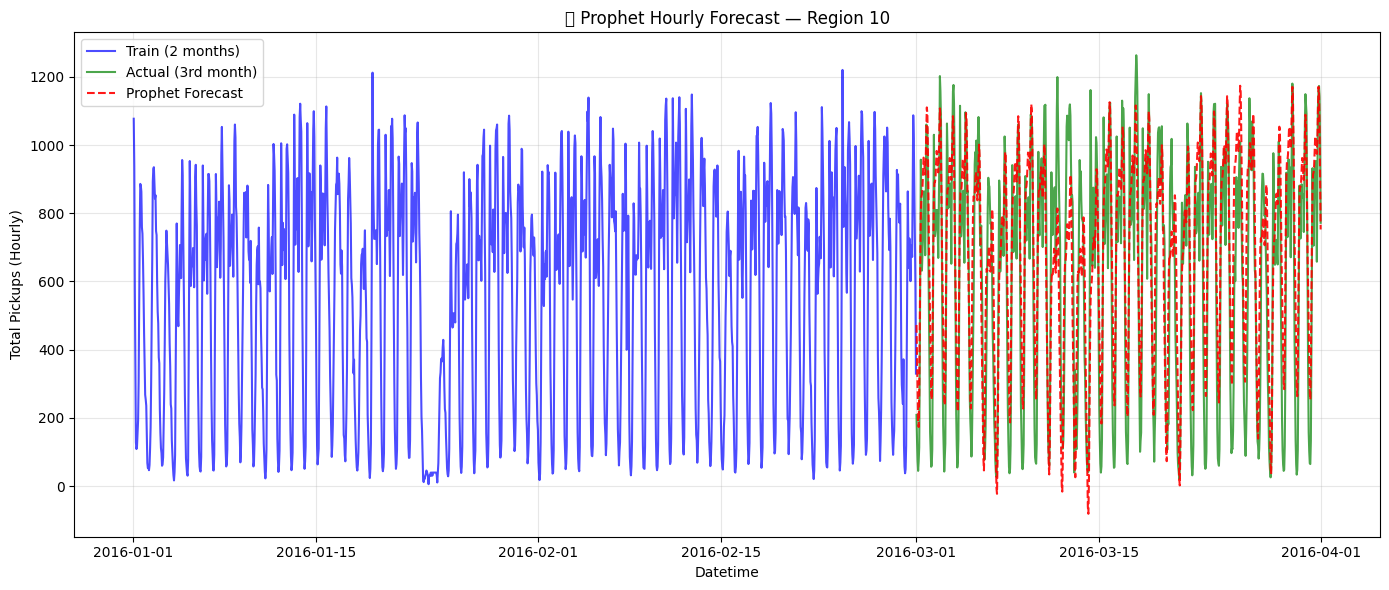

In [41]:
# ==========================================
# 🚖 Prophet Forecast (Hourly) for One Region
# ==========================================
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error
import matplotlib.pyplot as plt

# -----------------------------
# ⚙️ Step 1 — Select one region
# -----------------------------
region_id = 10  # Change this as needed

train_region = trainset[trainset["region"] == region_id].copy()
test_region  = testset[testset["region"] == region_id].copy()

print(f"🗺️ Region {region_id} — Train: {train_region.shape}, Test: {test_region.shape}")

# Ensure datetime index exists
train_region = train_region.reset_index()
test_region  = test_region.reset_index()

# -----------------------------
# ⏱️ Step 2 — Resample to 1-hour level
# -----------------------------
train_hourly = train_region.resample("1H", on="tpep_pickup_datetime").sum().reset_index()
test_hourly  = test_region.resample("1H", on="tpep_pickup_datetime").sum().reset_index()

print(f"Train hourly shape: {train_hourly.shape}, Test hourly shape: {test_hourly.shape}")

# -----------------------------
# 📊 Step 3 — Prepare Prophet data
# -----------------------------
prophet_train = train_hourly.rename(columns={"tpep_pickup_datetime": "ds", "total_pickups": "y"})
prophet_test  = test_hourly.rename(columns={"tpep_pickup_datetime": "ds", "total_pickups": "y"})

# -----------------------------
# 🧠 Step 4 — Train Prophet model
# -----------------------------
m = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)
m.add_seasonality(name='daily_cycle', period=24, fourier_order=10)

print("🚀 Training Prophet model (hourly)...")
m.fit(prophet_train)

# -----------------------------
# 🔮 Step 5 — Forecast test period
# -----------------------------
future = pd.DataFrame({"ds": prophet_test["ds"]})
forecast = m.predict(future)

# -----------------------------
# 📈 Step 6 — Evaluate MAPE
# -----------------------------
y_true = prophet_test["y"].values
y_pred = forecast["yhat"].values

mape = mean_absolute_percentage_error(y_true, y_pred)
print(f"✅ Prophet MAPE (Region {region_id} — Hourly): {mape:.4f}")

# -----------------------------
# 🎨 Step 7 — Visualization
# -----------------------------
plt.figure(figsize=(14, 6))
plt.plot(prophet_train["ds"], prophet_train["y"], label="Train (2 months)", color="blue", alpha=0.7)
plt.plot(prophet_test["ds"], prophet_test["y"], label="Actual (3rd month)", color="green", alpha=0.7)
plt.plot(forecast["ds"], forecast["yhat"], label="Prophet Forecast", color="red", linestyle="dashed", alpha=0.9)

plt.title(f"🧭 Prophet Hourly Forecast — Region {region_id}")
plt.xlabel("Datetime")
plt.ylabel("Total Pickups (Hourly)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()



In [42]:
# ==============================================
# 🔗 Combine Prophet (1-hour trend) + XGBoost (15-min features)
# ==============================================
import pandas as pd
from prophet import Prophet
from sklearn.metrics import mean_absolute_percentage_error

# ---------------------------
# ⚙️ Step 1 — Choose a region
# ---------------------------
region_id = 10  # Change as needed

train_region = trainset[trainset["region"] == region_id].copy()
test_region  = testset[testset["region"] == region_id].copy()

train_region = train_region.reset_index()
test_region  = test_region.reset_index()

# ---------------------------
# 🕓 Step 2 — Create hourly Prophet model
# ---------------------------
train_hourly = train_region.resample("1H", on="tpep_pickup_datetime").sum().reset_index()
prophet_train = train_hourly.rename(columns={"tpep_pickup_datetime": "ds", "total_pickups": "y"})

m = Prophet(
    daily_seasonality=True,
    weekly_seasonality=True,
    yearly_seasonality=False
)
m.add_seasonality(name='daily_cycle', period=24, fourier_order=10)

print(f"🚀 Training Prophet (hourly) for Region {region_id}...")
m.fit(prophet_train)

# Forecast for the full train+test period (to align with 15-min data)
all_times = pd.concat([train_region, test_region])["tpep_pickup_datetime"]
all_times_hourly = all_times.dt.floor("H").drop_duplicates().reset_index(drop=True)
future = pd.DataFrame({"ds": all_times_hourly})
forecast = m.predict(future)[["ds", "yhat"]]

# ---------------------------
# 🔄 Step 3 — Map hourly trend to 15-min data
# ---------------------------
# Assign Prophet’s hourly yhat to each 15-min timestamp
all_data = pd.concat([train_region, test_region])
all_data["hour"] = all_data["tpep_pickup_datetime"].dt.floor("H")

# Merge Prophet’s hourly trend with 15-min data
hybrid_data = pd.merge(all_data, forecast, left_on="hour", right_on="ds", how="left")

# Clean columns
hybrid_data = hybrid_data.drop(columns=["hour", "ds"])
hybrid_data.rename(columns={"yhat": "prophet_trend"}, inplace=True)

print(f"✅ Hybrid dataset shape: {hybrid_data.shape}")
print(hybrid_data[["tpep_pickup_datetime", "region", "total_pickups", "prophet_trend"]].head())

# ---------------------------
# ⚙️ Step 4 — Re-train XGBoost with new feature
# ---------------------------
from xgboost import XGBRegressor

# Define features
features = [
    "lag_1", "lag_2", "lag_3", "lag_4",
    "region", "avg_pickups", "day_of_week",
    "rolling_mean_3", "rolling_mean_6",
    "rolling_std_3", "rolling_std_6",
    "prophet_trend"   # 👈 new feature from Prophet
]

target = "total_pickups"

# Split hybrid data again
hybrid_train = hybrid_data[hybrid_data["tpep_pickup_datetime"] < "2016-03-01"]
hybrid_test  = hybrid_data[hybrid_data["tpep_pickup_datetime"] >= "2016-03-01"]

X_train, y_train = hybrid_train[features], hybrid_train[target]
X_test, y_test   = hybrid_test[features], hybrid_test[target]

# Fill missing trend values if any
X_train["prophet_trend"].fillna(method="bfill", inplace=True)
X_test["prophet_trend"].fillna(method="bfill", inplace=True)

# Train XGBoost with Prophet trend feature
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)
model.fit(X_train, y_train)

# Predict and evaluate
y_pred = model.predict(X_test)
mape = mean_absolute_percentage_error(y_test, y_pred)
print(f"💡 Hybrid Prophet + XGBoost MAPE: {mape:.4f}")


14:59:26 - cmdstanpy - INFO - Chain [1] start processing


🚀 Training Prophet (hourly) for Region 10...


14:59:26 - cmdstanpy - INFO - Chain [1] done processing


✅ Hybrid dataset shape: (8732, 14)
  tpep_pickup_datetime  region  total_pickups  prophet_trend
0  2016-01-01 01:00:00      10            298     292.047611
1  2016-01-01 01:15:00      10            262     292.047611
2  2016-01-01 01:30:00      10            250     292.047611
3  2016-01-01 01:45:00      10            267     292.047611
4  2016-01-01 02:00:00      10            278     182.769615
💡 Hybrid Prophet + XGBoost MAPE: 0.0213


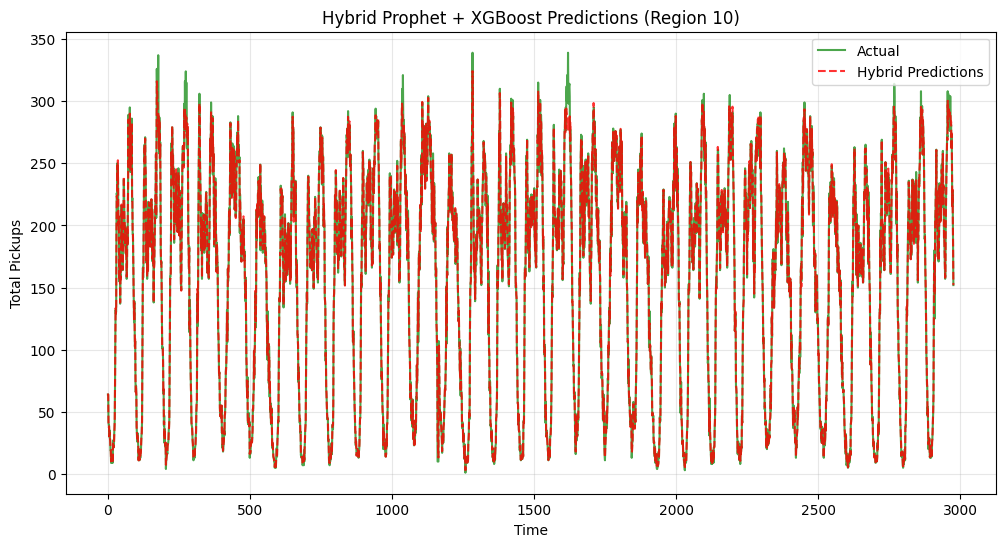

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(y_test.values, label="Actual", color="green", alpha=0.7)
plt.plot(y_pred, label="Hybrid Predictions", color="red", linestyle="dashed", alpha=0.8)
plt.title(f"Hybrid Prophet + XGBoost Predictions (Region {region_id})")
plt.xlabel("Time")
plt.ylabel("Total Pickups")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [44]:
import pandas as pd
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings("ignore")

# ======================================
# ⚙️ Step 1 — Setup
# ======================================

# Features you already engineered:
features = [
    "lag_1", "lag_2", "lag_3", "lag_4",
    "region", "avg_pickups", "day_of_week",
    "rolling_mean_3", "rolling_mean_6",
    "rolling_std_3", "rolling_std_6",
    "prophet_trend"  # 👈 new hybrid feature
]
target = "total_pickups"

region_ids = sorted(trainset["region"].unique())
region_results = []

print(f"🧭 Found {len(region_ids)} regions: {region_ids}")

# ======================================
# 🚀 Step 2 — Loop through regions
# ======================================
for region_id in region_ids:
    print(f"\n=============================================")
    print(f"🚖 Training Hybrid Prophet+XGBoost for Region {region_id}")
    print("=============================================")

    # --------------------------
    # Load region-wise data
    # --------------------------
    train_region = trainset[trainset["region"] == region_id].reset_index()
    test_region  = testset[testset["region"] == region_id].reset_index()

    if train_region.empty or test_region.empty:
        print(f"⚠️ Skipping region {region_id} — no data.")
        continue

    # --------------------------
    # Prophet model (hourly)
    # --------------------------
    train_hourly = (
        train_region.resample("1H", on="tpep_pickup_datetime")
        .sum()
        .reset_index()
    )

    prophet_train = train_hourly.rename(columns={
        "tpep_pickup_datetime": "ds",
        "total_pickups": "y"
    })

    try:
        m = Prophet(
            daily_seasonality=True,
            weekly_seasonality=True,
            yearly_seasonality=False
        )
        m.add_seasonality(name="daily_cycle", period=24, fourier_order=10)
        m.fit(prophet_train)

        # Forecast over the combined period
        all_times = pd.concat([train_region, test_region])["tpep_pickup_datetime"]
        all_times_hourly = all_times.dt.floor("H").drop_duplicates().reset_index(drop=True)
        future = pd.DataFrame({"ds": all_times_hourly})
        forecast = m.predict(future)[["ds", "yhat"]]

    except Exception as e:
        print(f"❌ Prophet failed for region {region_id}: {e}")
        continue

    # --------------------------
    # Merge Prophet trend (hourly) into 15-min data
    # --------------------------
    all_data = pd.concat([train_region, test_region])
    all_data["hour"] = all_data["tpep_pickup_datetime"].dt.floor("H")

    hybrid_data = pd.merge(all_data, forecast, left_on="hour", right_on="ds", how="left")
    hybrid_data.drop(columns=["hour", "ds"], inplace=True)
    hybrid_data.rename(columns={"yhat": "prophet_trend"}, inplace=True)

    # --------------------------
    # Split back into train/test
    # --------------------------
    hybrid_train = hybrid_data[hybrid_data["tpep_pickup_datetime"] < "2016-03-01"]
    hybrid_test  = hybrid_data[hybrid_data["tpep_pickup_datetime"] >= "2016-03-01"]

    # Handle missing trend values
    hybrid_train["prophet_trend"].fillna(method="bfill", inplace=True)
    hybrid_test["prophet_trend"].fillna(method="bfill", inplace=True)

    # --------------------------
    # Train XGBoost with hybrid feature
    # --------------------------
    X_train, y_train = hybrid_train[features], hybrid_train[target]
    X_test, y_test   = hybrid_test[features], hybrid_test[target]

    model = XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        random_state=42,
        n_jobs=-1
    )
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    region_results.append({"region": region_id, "mape": mape})

    print(f"✅ Region {region_id}: Hybrid Prophet+XGBoost MAPE = {mape:.4f}")

# ======================================
# 📊 Step 3 — Region-wise summary
# ======================================
results_df = pd.DataFrame(region_results).sort_values(by="mape")
print("\n📊 Region-wise Hybrid MAPE Summary:")
print(results_df)

print(f"\n🏁 Average Hybrid MAPE across all regions: {results_df['mape'].mean():.4f}")


🧭 Found 30 regions: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]

🚖 Training Hybrid Prophet+XGBoost for Region 0


15:03:40 - cmdstanpy - INFO - Chain [1] start processing
15:03:41 - cmdstanpy - INFO - Chain [1] done processing


✅ Region 0: Hybrid Prophet+XGBoost MAPE = 0.0266

🚖 Training Hybrid Prophet+XGBoost for Region 1


15:03:42 - cmdstanpy - INFO - Chain [1] start processing
15:03:42 - cmdstanpy - INFO - Chain [1] done processing


✅ Region 1: Hybrid Prophet+XGBoost MAPE = 0.1143

🚖 Training Hybrid Prophet+XGBoost for Region 2


...

✅ Region 27: Hybrid Prophet+XGBoost MAPE = 0.0198

🚖 Training Hybrid Prophet+XGBoost for Region 28


15:04:27 - cmdstanpy - INFO - Chain [1] start processing
15:04:27 - cmdstanpy - INFO - Chain [1] done processing


✅ Region 28: Hybrid Prophet+XGBoost MAPE = 0.0419

🚖 Training Hybrid Prophet+XGBoost for Region 29


15:04:29 - cmdstanpy - INFO - Chain [1] start processing
15:04:29 - cmdstanpy - INFO - Chain [1] done processing


✅ Region 29: Hybrid Prophet+XGBoost MAPE = 0.0242

📊 Region-wise Hybrid MAPE Summary:
    region      mape
20      20  0.018214
27      27  0.019812
13      13  0.020566
9        9  0.021037
22      22  0.021274
10      10  0.021345
3        3  0.021366
29      29  0.024201
14      14  0.024959
23      23  0.025659
0        0  0.026589
7        7  0.026690
11      11  0.027898
15      15  0.029113
17      17  0.029150
26      26  0.030295
24      24  0.030896
5        5  0.031267
8        8  0.031427
19      19  0.032232
6        6  0.032554
18      18  0.032900
25      25  0.036119
21      21  0.037943
12      12  0.039221
28      28  0.041865
2        2  0.041937
16      16  0.054807
4        4  0.062168
1        1  0.114318

🏁 Average Hybrid MAPE across all regions: 0.0336


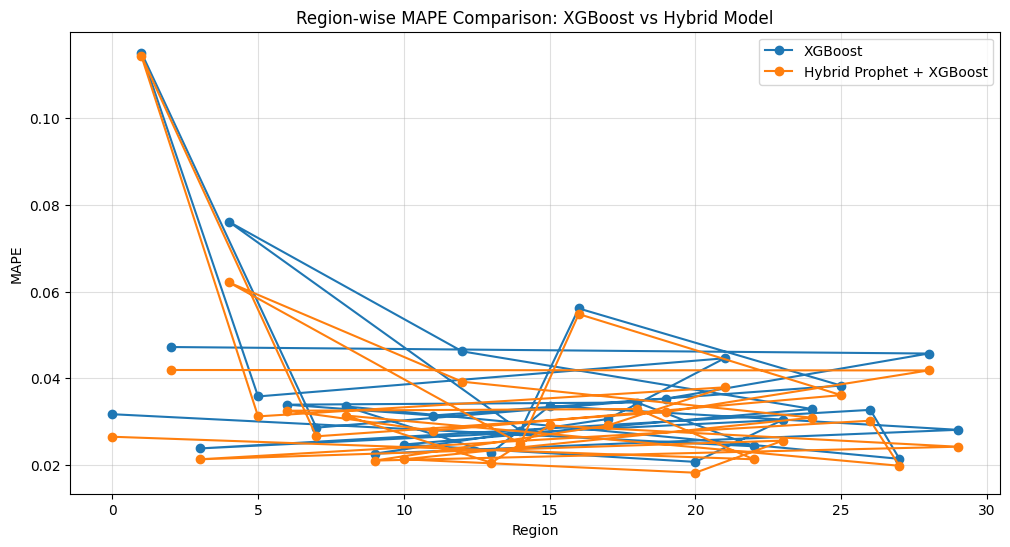

In [45]:
import matplotlib.pyplot as plt

results_compare = pd.DataFrame({
    "region": [0,22,18,6,11,25,16,14,4,12,24,10,20,23,3,26,27,8,13,15,29,9,17,21,5,1,7,19,28,2],
    "xgb_mape": [0.0317,0.0243,0.0344,0.0339,0.0314,0.0383,0.0561,0.0279,0.0761,0.0462,0.0329,0.0247,0.0207,0.0304,0.0238,0.0327,0.0214,0.0335,0.0228,0.0336,0.0281,0.0226,0.0306,0.0446,0.0358,0.1151,0.0286,0.0353,0.0457,0.0472],
    "hybrid_mape": [0.0265,0.0213,0.0329,0.0325,0.0279,0.0361,0.0548,0.0249,0.0621,0.0392,0.0309,0.0213,0.0182,0.0256,0.0213,0.0302,0.0198,0.0314,0.0205,0.0291,0.0242,0.0210,0.0291,0.0379,0.0312,0.1143,0.0266,0.0322,0.0418,0.0419]
})

plt.figure(figsize=(12,6))
plt.plot(results_compare["region"], results_compare["xgb_mape"], marker='o', label="XGBoost")
plt.plot(results_compare["region"], results_compare["hybrid_mape"], marker='o', label="Hybrid Prophet + XGBoost")
plt.xlabel("Region")
plt.ylabel("MAPE")
plt.title("Region-wise MAPE Comparison: XGBoost vs Hybrid Model")
plt.legend()
plt.grid(alpha=0.4)
plt.show()


In [47]:
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

# ====================================================
# ⚙️ Function: Train + Tune XGBoost for one region
# ====================================================
def tune_xgboost_region(region_id, trainset, testset, prophet_feature=True):
    print(f"\n🚀 Tuning XGBoost for Region {region_id}...")

    # Filter by region
    train_region = trainset[trainset["region"] == region_id].copy()
    test_region  = testset[testset["region"] == region_id].copy()

    # Skip if no data
    if train_region.empty or test_region.empty:
        print(f"⚠️ Skipping region {region_id} — not enough data.")
        return region_id, None, None

    # Feature columns
    features = [
        "lag_1", "lag_2", "lag_3", "lag_4",
        "avg_pickups", "day_of_week",
        "rolling_mean_3", "rolling_mean_6",
        "rolling_std_3", "rolling_std_6"
    ]
    if prophet_feature and "prophet_trend" in train_region.columns:
        features.append("prophet_trend")

    X_train, y_train = train_region[features], train_region["total_pickups"]
    X_test, y_test   = test_region[features], test_region["total_pickups"]

    # ------------------------------------------
    # 🎯 Define Optuna objective function
    # ------------------------------------------
    def objective(trial):
        params = {
            "n_estimators": trial.suggest_int("n_estimators", 100, 700),
            "max_depth": trial.suggest_int("max_depth", 3, 10),
            "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
            "subsample": trial.suggest_float("subsample", 0.6, 1.0),
            "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
            "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
            "gamma": trial.suggest_float("gamma", 0, 5),
            "reg_alpha": trial.suggest_float("reg_alpha", 0.0, 1.0),
            "reg_lambda": trial.suggest_float("reg_lambda", 0.0, 1.0),
            "random_state": 42,
            "n_jobs": -1
        }

        model = XGBRegressor(**params)
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        mape = mean_absolute_percentage_error(y_test, preds)
        return mape

    # ------------------------------------------
    # ⚡ Run Optuna optimization
    # ------------------------------------------
    study = optuna.create_study(direction="minimize")
    study.optimize(objective, n_trials=20, show_progress_bar=False)

    # ------------------------------------------
    # 🏆 Retrain best model & get final MAPE
    # ------------------------------------------
    best_params = study.best_params
    best_model = XGBRegressor(**best_params)
    best_model.fit(X_train, y_train)

    preds = best_model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, preds)

    print(f"✅ Region {region_id}: Best MAPE = {mape:.4f}")
    return region_id, mape, best_params


# ====================================================
# 🚀 Step 2: Loop through all regions
# ====================================================
region_results = []
all_regions = sorted(trainset["region"].unique())

for region_id in all_regions:
    region_id, mape, best_params = tune_xgboost_region(region_id, trainset, testset)
    if mape is not None:
        region_results.append({
            "region": region_id,
            "best_mape": mape,
            "best_params": best_params
        })

# ====================================================
# 📊 Step 3: Save and display results
# ====================================================
results_df = pd.DataFrame(region_results)
results_df = results_df.sort_values(by="best_mape")

print("\n📊 Region-wise Best XGBoost Results:")
print(results_df[["region", "best_mape"]])

results_df.to_csv("optuna_xgb_regionwise_results.csv", index=False)
print("\n💾 Results saved to optuna_xgb_regionwise_results.csv")

print(f"\n🏁 Average MAPE across all regions: {results_df['best_mape'].mean():.4f}")


[I 2025-10-30 15:19:42,317] A new study created in memory with name: no-name-93d72520-2d81-4d25-aacb-97d5c6c7b739



🚀 Tuning XGBoost for Region 0...


[I 2025-10-30 15:19:43,183] Trial 0 finished with value: 0.026663031429052353 and parameters: {'n_estimators': 622, 'max_depth': 6, 'learning_rate': 0.1418811384494799, 'subsample': 0.6903037958735069, 'colsample_bytree': 0.6932295889409386, 'min_child_weight': 2, 'gamma': 0.7099770734851546, 'reg_alpha': 0.04915330945518381, 'reg_lambda': 0.7010430563400015}. Best is trial 0 with value: 0.026663031429052353.
[I 2025-10-30 15:19:45,232] Trial 1 finished with value: 0.039559733122587204 and parameters: {'n_estimators': 618, 'max_depth': 9, 'learning_rate': 0.013778039258918358, 'subsample': 0.8039596537538136, 'colsample_bytree': 0.6363503016493515, 'min_child_weight': 10, 'gamma': 2.2970741758793203, 'reg_alpha': 0.30092273932430147, 'reg_lambda': 0.8992195970823371}. Best is trial 0 with value: 0.026663031429052353.
[I 2025-10-30 15:19:46,256] Trial 2 finished with value: 0.1171894371509552 and parameters: {'n_estimators': 334, 'max_depth': 8, 'learning_rate': 0.01057953405296079, 'su

✅ Region 0: Best MAPE = 0.0214

🚀 Tuning XGBoost for Region 1...


[I 2025-10-30 15:20:01,221] Trial 0 finished with value: 0.11722275614738464 and parameters: {'n_estimators': 244, 'max_depth': 7, 'learning_rate': 0.24839849693827368, 'subsample': 0.7499647912460448, 'colsample_bytree': 0.9188165207526833, 'min_child_weight': 8, 'gamma': 2.3348995067184104, 'reg_alpha': 0.47317679367298426, 'reg_lambda': 0.1107913492123539}. Best is trial 0 with value: 0.11722275614738464.
[I 2025-10-30 15:20:02,969] Trial 1 finished with value: 0.13238660991191864 and parameters: {'n_estimators': 557, 'max_depth': 10, 'learning_rate': 0.06840942130116556, 'subsample': 0.7666207084458139, 'colsample_bytree': 0.7567443568263228, 'min_child_weight': 7, 'gamma': 0.3049224922791888, 'reg_alpha': 0.5397662055539656, 'reg_lambda': 0.38796260536261606}. Best is trial 0 with value: 0.11722275614738464.
[I 2025-10-30 15:20:03,396] Trial 2 finished with value: 0.1519351601600647 and parameters: {'n_estimators': 190, 'max_depth': 7, 'learning_rate': 0.019312208749409716, 'subsa

...

✅ Region 27: Best MAPE = 0.0212

🚀 Tuning XGBoost for Region 28...


[I 2025-10-30 15:27:57,555] Trial 0 finished with value: 0.05351782962679863 and parameters: {'n_estimators': 547, 'max_depth': 9, 'learning_rate': 0.13382204223501903, 'subsample': 0.8850557010786421, 'colsample_bytree': 0.6812877643283526, 'min_child_weight': 7, 'gamma': 2.017019937034243, 'reg_alpha': 0.8139447836943852, 'reg_lambda': 0.05506721531002634}. Best is trial 0 with value: 0.05351782962679863.
[I 2025-10-30 15:27:59,264] Trial 1 finished with value: 0.04909205809235573 and parameters: {'n_estimators': 660, 'max_depth': 8, 'learning_rate': 0.03571149039796463, 'subsample': 0.944170624834424, 'colsample_bytree': 0.738121327541212, 'min_child_weight': 8, 'gamma': 2.0986771913919022, 'reg_alpha': 0.3461068125306921, 'reg_lambda': 0.6923104307874514}. Best is trial 1 with value: 0.04909205809235573.
[I 2025-10-30 15:28:00,330] Trial 2 finished with value: 0.050383973866701126 and parameters: {'n_estimators': 495, 'max_depth': 8, 'learning_rate': 0.12926497439661205, 'subsample

✅ Region 28: Best MAPE = 0.0326

🚀 Tuning XGBoost for Region 29...


[I 2025-10-30 15:28:13,738] Trial 0 finished with value: 0.16541926562786102 and parameters: {'n_estimators': 235, 'max_depth': 7, 'learning_rate': 0.011071308206193273, 'subsample': 0.6247445852628757, 'colsample_bytree': 0.7958939110697927, 'min_child_weight': 8, 'gamma': 4.233954031239257, 'reg_alpha': 0.5494068003886371, 'reg_lambda': 0.6816069492635756}. Best is trial 0 with value: 0.16541926562786102.
[I 2025-10-30 15:28:14,685] Trial 1 finished with value: 0.02804112248122692 and parameters: {'n_estimators': 420, 'max_depth': 7, 'learning_rate': 0.0433178367491192, 'subsample': 0.6026743932699815, 'colsample_bytree': 0.6498358804163383, 'min_child_weight': 6, 'gamma': 0.3517266355621662, 'reg_alpha': 0.35702699283381045, 'reg_lambda': 0.22234088517799377}. Best is trial 1 with value: 0.02804112248122692.
[I 2025-10-30 15:28:15,773] Trial 2 finished with value: 0.023211736232042313 and parameters: {'n_estimators': 391, 'max_depth': 8, 'learning_rate': 0.03128393034496879, 'subsam

✅ Region 29: Best MAPE = 0.0210

📊 Region-wise Best XGBoost Results:
    region  best_mape
20      20   0.016934
3        3   0.018372
22      22   0.018635
13      13   0.018788
10      10   0.019366
29      29   0.020965
27      27   0.021225
0        0   0.021356
18      18   0.021545
11      11   0.021646
6        6   0.022140
23      23   0.022854
26      26   0.023066
9        9   0.023581
15      15   0.024303
14      14   0.024818
17      17   0.026190
8        8   0.026306
7        7   0.027228
24      24   0.027530
5        5   0.028367
28      28   0.032553
25      25   0.033283
2        2   0.036919
19      19   0.037182
16      16   0.044156
12      12   0.045964
21      21   0.055561
4        4   0.057873
1        1   0.083118

💾 Results saved to optuna_xgb_regionwise_results.csv

🏁 Average MAPE across all regions: 0.0301


In [ ]:
import pandas as pd
trainset=pd.read_csv(r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\train.csv")
trainset=pd.read_csv(r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\train.csv")

In [4]:
testset=pd.read_csv(r"D:\datascience\campusx\PROJECTS\demand_preidction_experimentation\data\test.csv")

In [5]:
testset

,tpep_pickup_datetime,lag_1,lag_2,lag_3,lag_4,region,total_pickups,avg_pickups,day_of_week
0,2016-03-01 00:00:00,133.0,137.0,132.0,145.0,2,102,117.051154,1
1,2016-03-01 00:00:00,118.0,113.0,111.0,144.0,24,94,105.186891,1
2,2016-03-01 00:00:00,15.0,17.0,18.0,6.0,7,23,19.474897,1
3,2016-03-01 00:00:00,19.0,16.0,23.0,23.0,9,24,21.713852,1
4,2016-03-01 00:00:00,175.0,205.0,231.0,314.0,8,136,165.123156,1
...,...,...,...,...,...,...,...,...,...
89275,2016-03-31 23:45:00,297.0,287.0,279.0,335.0,24,295,295.011212,3
89276,2016-03-31 23:45:00,335.0,346.0,325.0,317.0,25,283,305.794516,3
89277,2016-03-31 23:45:00,337.0,410.0,371.0,381.0,26,317,338.551044,3
89278,2016-03-31 23:45:00,318.0,315.0,346.0,383.0,13,282,301.924648,3


In [6]:
import pandas as pd
import numpy as np
import json
from prophet import Prophet
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error

# ==============================================================
# ✅ LOAD DATA + OPTUNA RESULTS
# ==============================================================


optuna_results = pd.read_csv("optuna_xgb_regionwise_results.csv")

# Convert parameter strings → dicts
optuna_results['best_params'] = optuna_results['best_params'].apply(
    lambda x: json.loads(x.replace("'", '"')) if isinstance(x, str) else x
)

# ==============================================================
# ⚙️ REGION-WISE HYBRID FUNCTION
# ==============================================================
def hybrid_prophet_xgb_region(region_id):
    print(f"\n🚀 Running Hybrid Prophet + XGBoost (Optuna Params) for Region {region_id}...")

    # 1️⃣ Filter data
    train_region = trainset[trainset["region"] == region_id].copy()
    test_region  = testset[testset["region"] == region_id].copy()
    if train_region.empty or test_region.empty:
        print(f"⚠️ Skipping region {region_id} — no data.")
        return None, None

    # Ensure datetime
    train_region["tpep_pickup_datetime"] = pd.to_datetime(train_region["tpep_pickup_datetime"])
    test_region["tpep_pickup_datetime"]  = pd.to_datetime(test_region["tpep_pickup_datetime"])

    # --------------------------------------------------------------
    # 🧠 STEP 1 — Train Prophet (hourly trend)
    # --------------------------------------------------------------
    train_hourly = (
        train_region.resample("1H", on="tpep_pickup_datetime")
        .sum()
        .reset_index()
    )
    prophet_train = train_hourly.rename(columns={"tpep_pickup_datetime": "ds", "total_pickups": "y"})

    m = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=False)
    m.add_seasonality(name='daily_cycle', period=24, fourier_order=10)
    m.fit(prophet_train)

    # Predict for all timestamps
    all_times = pd.concat([train_region, test_region])["tpep_pickup_datetime"]
    all_times_hourly = all_times.dt.floor("H").drop_duplicates().reset_index(drop=True)
    future = pd.DataFrame({"ds": all_times_hourly})
    forecast = m.predict(future)[["ds", "yhat"]]

    # --------------------------------------------------------------
    # 🔗 STEP 2 — Merge Prophet’s hourly yhat → 15-min data
    # --------------------------------------------------------------
    all_data = pd.concat([train_region, test_region])
    all_data["hour"] = all_data["tpep_pickup_datetime"].dt.floor("H")
    hybrid_data = pd.merge(all_data, forecast, left_on="hour", right_on="ds", how="left")
    hybrid_data = hybrid_data.drop(columns=["hour", "ds"])
    hybrid_data.rename(columns={"yhat": "prophet_trend"}, inplace=True)

    # --------------------------------------------------------------
    # ⚙️ STEP 3 — Train XGBoost using Optuna best params
    # --------------------------------------------------------------
    features = [
        "lag_1", "lag_2", "lag_3", "lag_4",
        "avg_pickups", "day_of_week",
        "rolling_mean_3", "rolling_mean_6",
        "rolling_std_3", "rolling_std_6",
        "prophet_trend"
    ]
    target = "total_pickups"

    # Train/test split by date
    hybrid_train = hybrid_data[hybrid_data["tpep_pickup_datetime"] < "2016-03-01"]
    hybrid_test  = hybrid_data[hybrid_data["tpep_pickup_datetime"] >= "2016-03-01"]

    X_train, y_train = hybrid_train[features], hybrid_train[target]
    X_test, y_test   = hybrid_test[features], hybrid_test[target]

    X_train["prophet_trend"].fillna(method="bfill", inplace=True)
    X_test["prophet_trend"].fillna(method="bfill", inplace=True)

    # Get region’s tuned params
    best_params_row = optuna_results.loc[optuna_results["region"] == region_id]
    if best_params_row.empty:
        print(f"⚠️ No Optuna params found for region {region_id}, using defaults.")
        best_params = dict(n_estimators=300, learning_rate=0.05, max_depth=6)
    else:
        best_params = best_params_row["best_params"].values[0]

    model = XGBRegressor(**best_params)
    model.fit(X_train, y_train)

    # --------------------------------------------------------------
    # 📈 STEP 4 — Evaluate Hybrid Model
    # --------------------------------------------------------------
    y_pred = model.predict(X_test)
    mape = mean_absolute_percentage_error(y_test, y_pred)
    print(f"✅ Region {region_id}: Hybrid Prophet + XGBoost MAPE = {mape:.4f}")

    return region_id, mape

# ==============================================================
# 🔁 LOOP THROUGH ALL REGIONS
# ==============================================================
regions = sorted(trainset["region"].unique())
results = []

for region_id in regions:
    result = hybrid_prophet_xgb_region(region_id)
    if result[0] is not None:
        results.append(result)

# ==============================================================
# 📊 SAVE + DISPLAY SUMMARY
# ==============================================================
hybrid_results = pd.DataFrame(results, columns=["region", "hybrid_mape"])
hybrid_results.sort_values("hybrid_mape", inplace=True)
hybrid_results.to_csv("hybrid_prophet_xgb_optuna_results.csv", index=False)

print("\n📊 Hybrid Prophet + XGBoost (Optuna) Summary:")
print(hybrid_results.head(10))
print(f"\n🏁 Average Hybrid MAPE across all regions: {hybrid_results['hybrid_mape'].mean():.4f}")



🚀 Running Hybrid Prophet + XGBoost (Optuna Params) for Region 0...


C:\Users\apoor\AppData\Local\Temp\ipykernel_41528\2113226747.py:41: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  train_region.resample("1H", on="tpep_pickup_datetime")
19:34:55 - cmdstanpy - INFO - Chain [1] start processing
19:34:55 - cmdstanpy - INFO - Chain [1] done processing
C:\Users\apoor\AppData\Local\Temp\ipykernel_41528\2113226747.py:53: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_times_hourly = all_times.dt.floor("H").drop_duplicates().reset_index(drop=True)
C:\Users\apoor\AppData\Local\Temp\ipykernel_41528\2113226747.py:61: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  all_data["hour"] = all_data["tpep_pickup_datetime"].dt.floor("H")


KeyError: "['rolling_mean_3', 'rolling_mean_6', 'rolling_std_3', 'rolling_std_6'] not in index"

In [57]:
train_region

,tpep_pickup_datetime,lag_1,lag_2,lag_3,lag_4,region,total_pickups,avg_pickups,day_of_week,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6
0,2016-01-01 01:00:00,352.0,353.0,364.0,210.0,29,390,367.789913,4,199.666667,14.977761,21.000000,5.932959
1,2016-01-01 01:15:00,390.0,352.0,353.0,364.0,29,344,354.705461,4,199.666667,14.977761,21.000000,5.932959
2,2016-01-01 01:30:00,344.0,390.0,352.0,353.0,29,321,336.167457,4,351.666667,35.133080,21.000000,5.932959
3,2016-01-01 01:45:00,321.0,344.0,390.0,352.0,29,310,321.775356,4,325.000000,17.349352,21.000000,5.932959
4,2016-01-01 02:00:00,310.0,321.0,344.0,390.0,29,295,307.048910,4,308.666667,13.051181,21.000000,5.932959
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5751,2016-02-29 22:45:00,138.0,163.0,202.0,250.0,29,127,142.311146,0,142.666667,18.448125,185.833333,51.121098
5752,2016-02-29 23:00:00,127.0,138.0,163.0,202.0,29,130,135.540016,0,131.666667,5.686241,168.333333,48.845334
5753,2016-02-29 23:15:00,130.0,127.0,138.0,163.0,29,108,120.393007,0,121.666667,11.930353,144.666667,33.284631
5754,2016-02-29 23:30:00,108.0,130.0,127.0,138.0,29,86,101.476853,0,108.000000,22.000000,125.333333,26.272926


In [65]:

train_region

,index,tpep_pickup_datetime,lag_1,lag_2,lag_3,lag_4,region,total_pickups,avg_pickups,day_of_week,rolling_mean_3,rolling_std_3,rolling_mean_6,rolling_std_6
0,11,2016-01-01 01:00:00,270.0,243.0,184.0,126.0,10,298,272.177762,4,199.666667,14.977761,21.000000,5.932959
1,53,2016-01-01 01:15:00,298.0,270.0,243.0,184.0,10,262,266.579993,4,199.666667,14.977761,21.000000,5.932959
2,70,2016-01-01 01:30:00,262.0,298.0,270.0,243.0,10,250,257.460997,4,270.000000,24.979992,21.000000,5.932959
3,114,2016-01-01 01:45:00,250.0,262.0,298.0,270.0,10,267,262.707449,4,259.666667,8.736895,21.000000,5.932959
4,122,2016-01-01 02:00:00,267.0,250.0,262.0,298.0,10,278,271.118352,4,265.000000,14.106736,21.000000,5.932959
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5751,172554,2016-02-29 22:45:00,126.0,159.0,195.0,179.0,10,110,126.461554,0,131.666667,24.986663,155.166667,31.958828
5752,172589,2016-02-29 23:00:00,110.0,126.0,159.0,195.0,10,95,109.157699,0,110.333333,15.502688,144.000000,39.829637
5753,172591,2016-02-29 23:15:00,95.0,110.0,126.0,159.0,10,85,95.870965,0,96.666667,12.583057,128.333333,41.750050
5754,172623,2016-02-29 23:30:00,85.0,95.0,110.0,126.0,10,82,88.241934,0,87.333333,6.806859,109.500000,29.289930


In [67]:
trainset


,tpep_pickup_datetime,lag_1,lag_2,lag_3,lag_4,region,total_pickups,avg_pickups,day_of_week
0,2016-01-01 01:00:00,241.0,235.0,326.0,138.0,0,250,245.318200,4
1,2016-01-01 01:00:00,117.0,124.0,92.0,30.0,22,121,115.159113,4
2,2016-01-01 01:00:00,284.0,246.0,253.0,157.0,18,257,258.156275,4
3,2016-01-01 01:00:00,306.0,401.0,416.0,239.0,6,251,289.096269,4
4,2016-01-01 01:00:00,387.0,422.0,402.0,156.0,11,413,396.477463,4
...,...,...,...,...,...,...,...,...,...
172675,2016-02-29 23:45:00,205.0,231.0,314.0,270.0,8,175,200.718125,0
172676,2016-02-29 23:45:00,16.0,6.0,9.0,9.0,21,11,11.504424,0
172677,2016-02-29 23:45:00,140.0,171.0,177.0,206.0,6,118,136.046955,0
172678,2016-02-29 23:45:00,49.0,64.0,67.0,77.0,15,30,42.534871,0
